# Patrón 1: ReAct: Detección de Fraude Financiero

## Dataset elegido: PaySim (Kaggle)
PaySim simula transacciones de dinero móvil basadas en registros reales de un mes de logs financieros de un servicio implementado en un país africano. GitHub Es el dataset de referencia para detección de fraude y encaja perfectamente con el patrón ReAct porque el analista no sabe de antemano qué herramientas necesita — el agente razona en cada iteración.


```bash
# Con Kaggle CLI
pip install kaggle
kaggle datasets download -d ealaxi/paysim1
unzip paysim1.zip
```

## Estructura del Dataset

DATASET:
  Nombre  : PaySim — Synthetic Financial Datasets For Fraud Detection
  URL     : https://www.kaggle.com/datasets/ealaxi/paysim1
  Descarga: kaggle datasets download -d ealaxi/paysim1
  Archivo : PS_20174392719_1491204439457_log.csv  (~470 MB, ~6.3M filas)
  Licencia: CC0 Public Domain

  Columnas:

* step          - hora de la transacción (1 step = 1 hora, 744 steps = 30 días)
* type          - CASH-IN | CASH-OUT | DEBIT | PAYMENT | TRANSFER
* amount        - monto en moneda local
* nameOrig      - ID del cliente origen
* oldbalanceOrg - saldo origen antes de la transacción
* newbalanceOrig- saldo origen después de la transacción
* nameDest      - ID del receptor (C=cliente, M=merchant)
* oldbalanceDest- saldo receptor antes
* newbalanceDest- saldo receptor después
* isFraud       - 1 si es fraude real (ground truth)
* isFlaggedFraud- 1 si el sistema interno lo bloqueó (>= 200,000)



## Por qué encaja con el Patrón ReAct
El bucle Reason+Act es ideal aquí porque:

1. Un analista pregunta en lenguaje natural: "¿Qué tipos de transacción tienen más fraude?"
2. El LLM razona: "necesito analyze_fraud_by_type"
3. Ejecuta la tool → recibe estadísticas reales del CSV
4. Razona de nuevo: "los datos muestran solo TRANSFER y CASH-OUT tienen fraude, puedo responder"
5. Responde con insight de negocio

## Las 6 Tools del Agente
|Tool |Qué hace |
|:----|:--------|
|get_dataset_summary| Resumen general: totales, tipos, % fraude|
|analyze_fraud_by_type| Fraude por tipo (TRANSFER vs CASH-OUT vs otros)|
|get_high_risk_transactions| Top N transacciones de mayor monto y riesgo|
|analyze_balance_discrepancy| Detecta cuando oldBalance - amount ≠ newBalance|
|get_fraud_time_distribution| En qué horas del día concentra el fraude
|calculate_fraud_exposure| Exposición monetaria total por tipo|

## Requerimientos:

```bash

pip install langgraph langchain langchain-anthropic pandas
```

Diagrama:
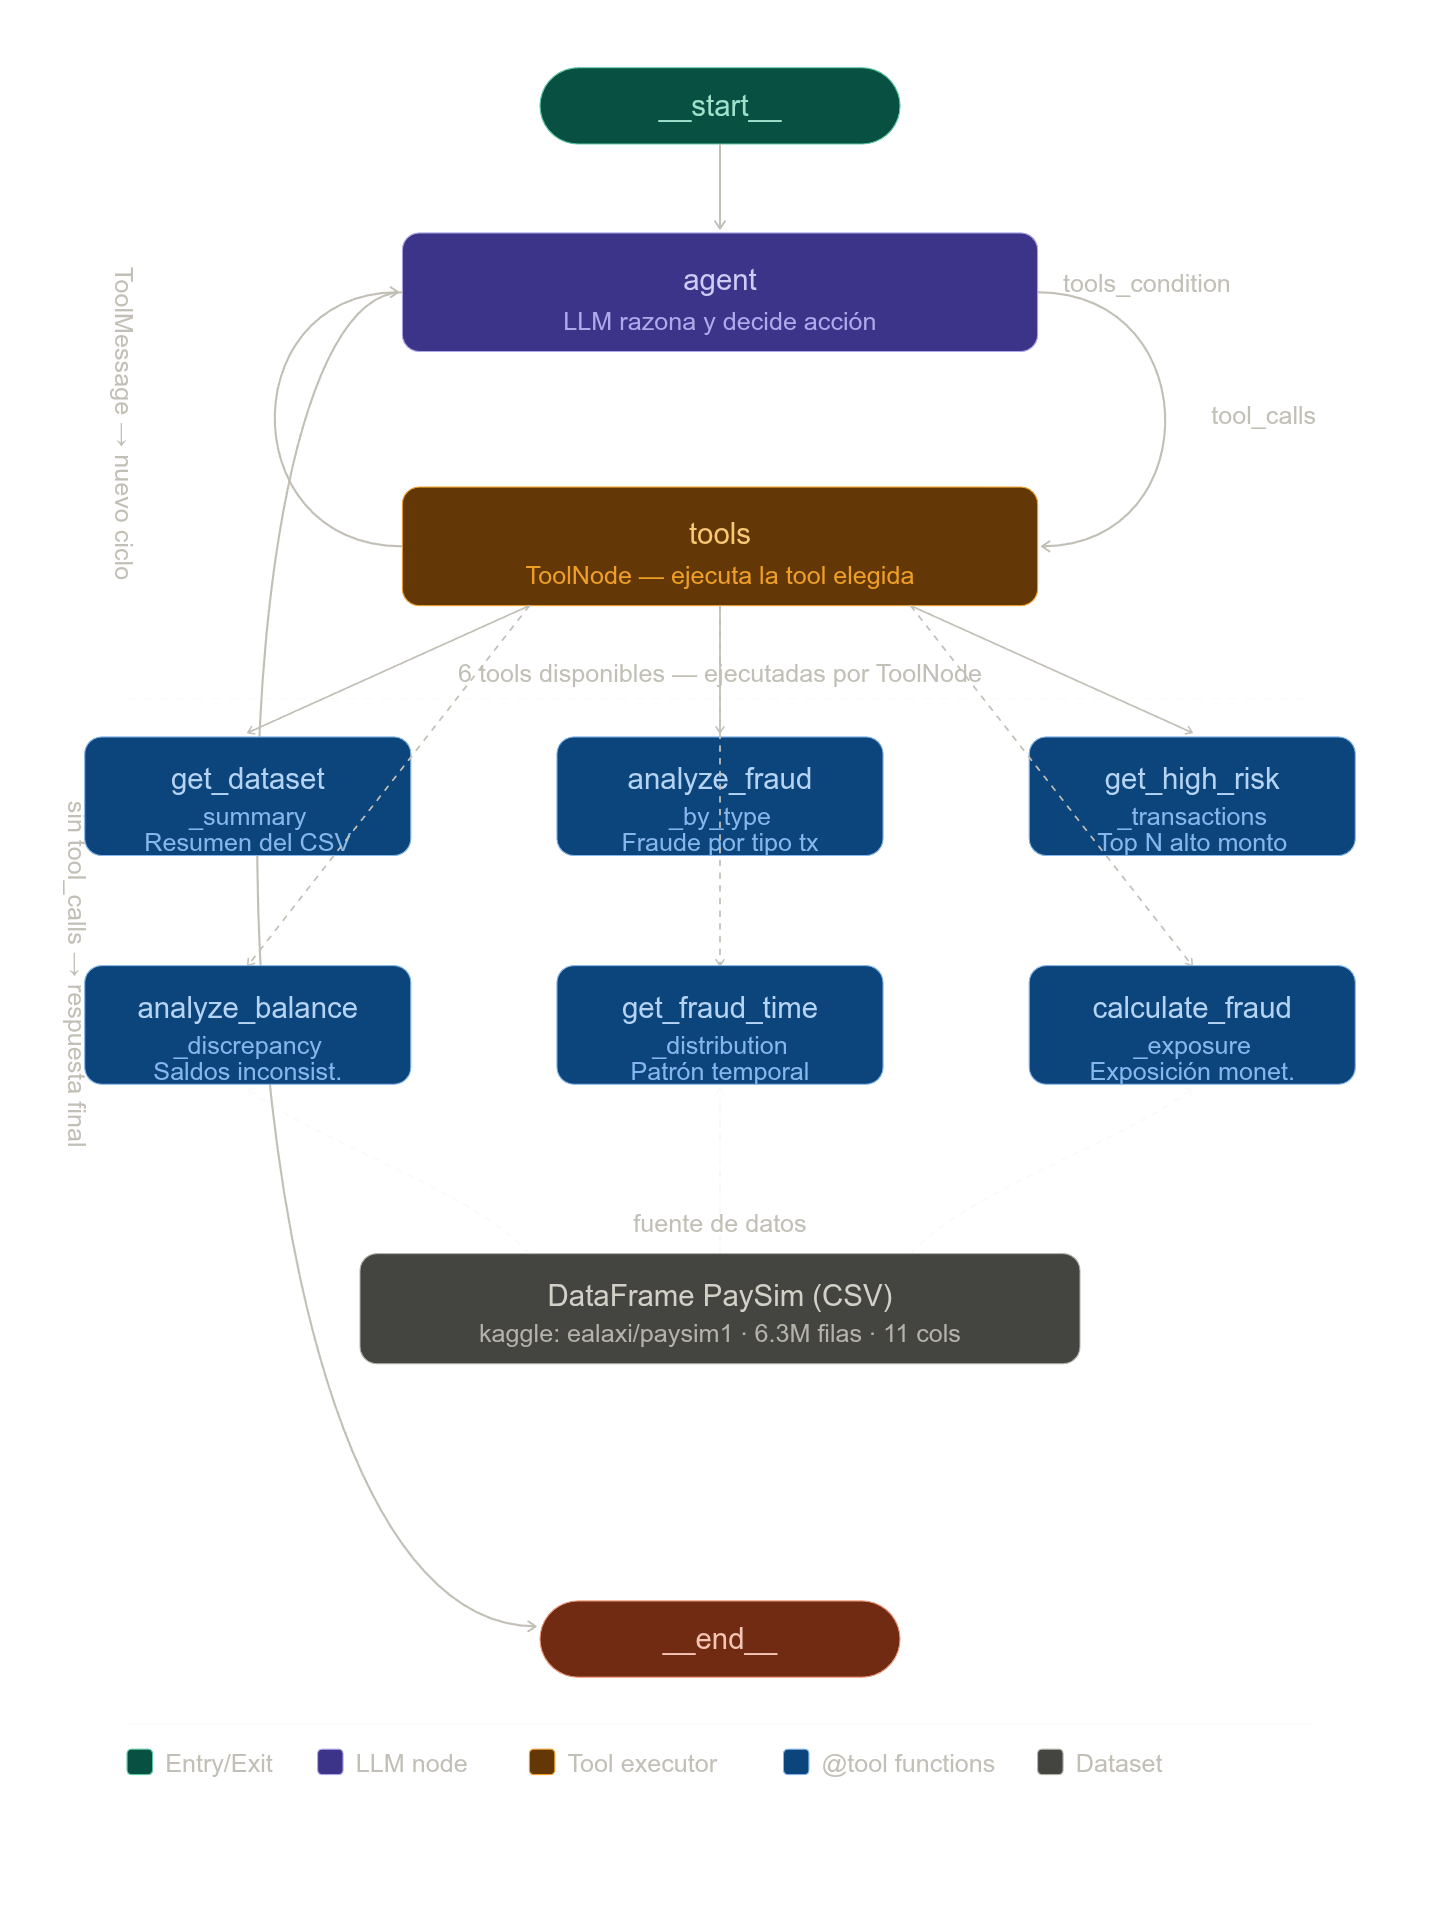


Nodos/Componentes:
|Nodo/Componente|Tipo|Función|Descripción|
|:--------------|:---|:------|:----------|
|__start__|Entry point|Punto de entrada del grafo|Nodo virtual de LangGraph que inicia el flujo. Recibe el mensaje del usuario (HumanMessage) e inyecta el estado inicial a MessagesState.|
|agent — call_model|LLM Node|Razona y decide la próxima acción|Invoca claude-sonnet-4-6 con las tools vinculadas (llm.bind_tools). El modelo analiza el historial de mensajes, razona en cadena y decide si llamar una tool o emitir la respuesta final.|
|tools_condition|Conditional Edge|Router dinámico post-LLM|Función prebuilt de LangGraph. Inspecciona el último mensaje: si contiene tool_calls enruta al nodo tools; si no hay tool calls, enruta a __end__ con la respuesta final.|
|tools — ToolNode|Tool Executor|Ejecuta la herramienta seleccionada|Nodo prebuilt de LangGraph. Recibe el AIMessage con tool_calls, despacha la tool correspondiente, captura el resultado y lo añade al estado como ToolMessage para que el LLM continúe razonando.|
|get_dataset_summary|Tool|Estadísticas generales del CSV|Lee el DataFrame PaySim y calcula: total de filas, conteo y porcentaje de fraudes (isFraud), fraudes bloqueados (isFlaggedFraud), distribución por tipo y estadísticas de monto (describe()).|
|analyze_fraud_by_type|Tool|Fraude agrupado por tipo de transacción|Ejecuta un groupby("type") calculando total de transacciones, conteo de fraudes y porcentaje de fraude por tipo (TRANSFER, CASH-OUT, PAYMENT, CASH-IN, DEBIT). Ordena descendente por fraudes.|
|get_high_risk_transactions|Tool|Top N transacciones de mayor monto|Filtra filas donde amount >= min_amount y type in [TRANSFER, CASH-OUT]. Devuelve las N filas con monto más alto con columnas clave: step, type, amount, nameOrig, nameDest, isFraud, isFlaggedFraud.|
|analyze_balance_discrepancy|Tool|Detecta inconsistencias de saldo|Calcula expected = oldbalanceOrg - amount y compara con newbalanceOrig. Si la diferencia es mayor a 1.0 marca como discrepancia. Reporta cuántas discrepancias son fraude real y cuántas son legítimas.|
|get_fraud_time_distribution|Tool|Patrón temporal del fraude|Filtra registros con isFraud == 1 y agrupa por columna step (1 step = 1 hora). Devuelve los 10 períodos horarios con mayor concentración de fraudes en los 30 días simulados.|
|calculate_fraud_exposure|Tool|Exposición monetaria por tipo|Para un transaction_type dado, filtra fraudes reales y calcula: monto total expuesto (sum), monto promedio por fraude (mean) y monto máximo en una sola transacción fraudulenta.|
|DataFrame PaySim|Fuente de datos|Dataset de transacciones móviles|CSV descargado de Kaggle (ealaxi/paysim1). 6.3M filas, 11 columnas. Cargado en memoria con Pandas al inicio. Si no existe el CSV, _generate_demo_data() crea 5K filas sintéticas compatibles para pruebas sin Kaggle.|
|__end__|Exit point|Punto de salida del grafo|Nodo virtual de LangGraph. El flujo llega aquí cuando el LLM emite un AIMessage sin tool_calls, indicando que tiene suficiente información para responder al usuario.|


### Cuándo usarlo
- ✅ Agentes simples con set de herramientas definido
- ✅ Prototipado rápido de agentes conversacionales
- ✅ Tasks que requieren búsqueda + razonamiento iterativo
- ❌ No ideal para tareas que requieren múltiples agentes especializados


In [1]:
import sys
print(sys.executable)

/home/ernesto/PycharmProjects/Langgraph_tutorials/.venv/bin/python


In [2]:
!pip install langgraph langchain langchain-anthropic pandas pydantic python-dotenv

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.14/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [4]:
import pandas as pd
from IPython.display import Image, display


In [5]:
from langchain.tools import tool
from langchain_anthropic import ChatAnthropic
from langchain.agents import create_agent
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition


In [6]:
CSV_PATH = os.getenv("PAYSIM_CSV", "PS_20174392719_1491204439457_log.csv")
CSV_PATH

'PS_20174392719_1491204439457_log.csv'

In [7]:
def _generate_demo_data(n: int = 5_000) -> pd.DataFrame:
    """Genera un mini-dataset PaySim compatible para correr sin Kaggle."""
    import numpy as np
    rng = np.random.default_rng(42)

    types = rng.choice(
        ["CASH-OUT", "PAYMENT", "CASH-IN", "TRANSFER", "DEBIT"],
        size=n,
        p=[0.35, 0.34, 0.22, 0.08, 0.01],
    )
    amounts   = rng.exponential(scale=50_000, size=n).round(2)
    is_fraud  = ((types == "TRANSFER") | (types == "CASH-OUT")) & (amounts > 200_000)
    is_fraud  = is_fraud & (rng.random(n) < 0.002)   # ~0.2% fraude

    df = pd.DataFrame({
        "step"          : rng.integers(1, 745, size=n),
        "type"          : types,
        "amount"        : amounts,
        "nameOrig"      : [f"C{rng.integers(1e8, 9e8)}" for _ in range(n)],
        "oldbalanceOrg" : rng.uniform(0, 500_000, size=n).round(2),
        "newbalanceOrig": rng.uniform(0, 500_000, size=n).round(2),
        "nameDest"      : [f"C{rng.integers(1e8, 9e8)}" for _ in range(n)],
        "oldbalanceDest": rng.uniform(0, 1_000_000, size=n).round(2),
        "newbalanceDest": rng.uniform(0, 1_000_000, size=n).round(2),
        "isFraud"       : is_fraud.astype(int),
        "isFlaggedFraud": ((amounts >= 200_000) & is_fraud).astype(int),
    })
    print(f"✅ Dataset demo generado: {len(df):,} filas  |  fraudes: {df['isFraud'].sum()}")
    return df


In [8]:
def load_data(path: str, sample: int = 50_000) -> pd.DataFrame:
    """Carga el CSV de PaySim con una muestra para prototipado rápido."""
    try:
        df = pd.read_csv(path, nrows=sample)
        print(f"✅ Dataset cargado: {len(df):,} filas  |  columnas: {list(df.columns)}")
        return df
    except FileNotFoundError:
        print("⚠️  CSV no encontrado. Generando datos sintéticos de demo...")
        return _generate_demo_data(sample)


In [9]:
DF = load_data(CSV_PATH)
DF.head()

⚠️  CSV no encontrado. Generando datos sintéticos de demo...
✅ Dataset demo generado: 50,000 filas  |  fraudes: 0


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,467,CASH-IN,43785.44,C799426260,485620.36,304325.38,C607409813,250191.30,781823.09,0,0
1,186,PAYMENT,34063.46,C396068321,62230.09,493434.71,C488818257,919340.04,815735.81,0,0
2,134,CASH-IN,1956.01,C580485650,38095.67,186838.67,C285523480,609552.90,471404.12,0,0
3,409,CASH-IN,58145.26,C408316915,118098.22,325364.48,C786479655,177215.71,200427.14,0,0
4,660,CASH-OUT,38983.27,C136603407,341373.01,260338.06,C185617401,260480.87,456936.60,0,0


# ---------------------------------------------------------------------------
# 2. HERRAMIENTAS (Tools) del Agente ReAct
# ---------------------------------------------------------------------------


In [10]:
@tool
def get_dataset_summary() -> str:
    """
    Devuelve un resumen general del dataset PaySim:
    total de transacciones, tipos, porcentaje de fraude y estadísticas básicas.
    """
    total        = len(DF)
    fraud_count  = int(DF["isFraud"].sum())
    fraud_pct    = fraud_count / total * 100
    flagged      = int(DF["isFlaggedFraud"].sum())
    type_counts  = DF["type"].value_counts().to_dict()
    amount_stats = DF["amount"].describe().round(2).to_dict()

    return (
        f"📊 RESUMEN DATASET PaySim\n"
        f"  Total transacciones : {total:,}\n"
        f"  Fraudes reales      : {fraud_count:,} ({fraud_pct:.3f}%)\n"
        f"  Fraudes bloqueados  : {flagged:,}\n"
        f"  Tipos de transacción: {type_counts}\n"
        f"  Monto (estadísticas): {amount_stats}"
    )


In [11]:
@tool
def analyze_fraud_by_type() -> str:
    """
    Analiza la distribución de fraude por tipo de transacción.
    Devuelve conteo y porcentaje de fraude para cada tipo (TRANSFER, CASH-OUT, etc.).
    """
    result = (
        DF.groupby("type")
        .agg(
            total=("isFraud", "count"),
            fraudes=("isFraud", "sum"),
        )
        .assign(pct_fraude=lambda x: (x["fraudes"] / x["total"] * 100).round(3))
        .sort_values("fraudes", ascending=False)
    )
    return f"🔍 FRAUDE POR TIPO\n{result.to_string()}"


In [12]:
@tool
def get_high_risk_transactions(min_amount: float = 200_000.0, limit: int = 10) -> str:
    """
    Devuelve las transacciones de alto riesgo:
    monto >= min_amount Y tipo TRANSFER o CASH-OUT.
    Útil para identificar los casos más críticos.

    Args:
        min_amount: Monto mínimo para considerar alto riesgo (default: 200,000).
        limit: Número máximo de registros a retornar (default: 10).
    """
    mask = (
        (DF["amount"] >= min_amount)
        & (DF["type"].isin(["TRANSFER", "CASH-OUT"]))
    )
    subset = DF[mask].nlargest(limit, "amount")[
        ["step", "type", "amount", "nameOrig", "nameDest", "isFraud", "isFlaggedFraud"]
    ]
    if subset.empty:
        return f"No se encontraron transacciones >= {min_amount:,.0f}"
    return f"🚨 TOP TRANSACCIONES ALTO RIESGO (>= {min_amount:,.0f})\n{subset.to_string(index=False)}"


In [13]:
@tool
def analyze_balance_discrepancy() -> str:
    """
    Detecta transacciones donde el saldo del origen no cuadra después de la transacción.
    Una discrepancia (oldBalance - amount != newBalance) puede ser señal de fraude.
    Devuelve estadísticas sobre discrepancias detectadas.
    """
    df_work = DF.copy()
    df_work["expected_new_balance"] = (df_work["oldbalanceOrg"] - df_work["amount"]).round(2)
    df_work["discrepancia"] = (
        (df_work["newbalanceOrig"] - df_work["expected_new_balance"]).abs() > 1.0
    )
    disc_total   = int(df_work["discrepancia"].sum())
    disc_fraud   = int(df_work[df_work["discrepancia"] & (df_work["isFraud"] == 1)].shape[0])
    disc_legit   = disc_total - disc_fraud

    return (
        f"⚖️ ANÁLISIS DE DISCREPANCIAS DE SALDO\n"
        f"  Transacciones con discrepancia : {disc_total:,}\n"
        f"    → Son fraude real            : {disc_fraud:,}\n"
        f"    → Son legítimas (dato curioso): {disc_legit:,}\n"
        f"  Precisión de discrepancia como señal: "
        f"{disc_fraud / disc_total * 100:.1f}% (de las discrepantes, son fraude)"
        if disc_total > 0
        else "No se detectaron discrepancias."
    )


In [14]:
@tool
def get_fraud_time_distribution() -> str:
    """
    Analiza en qué horas del día (steps) ocurre más fraude.
    Devuelve los 10 períodos con mayor concentración de fraude.
    Ayuda a identificar patrones temporales sospechosos.
    """
    fraud_df = DF[DF["isFraud"] == 1]
    if fraud_df.empty:
        return "No hay fraudes en el dataset cargado."

    time_dist = (
        fraud_df.groupby("step")
        .size()
        .reset_index(name="fraudes")
        .nlargest(10, "fraudes")
    )
    return (
        f"🕐 DISTRIBUCIÓN TEMPORAL DEL FRAUDE (Top 10 períodos)\n"
        f"{time_dist.to_string(index=False)}\n"
        f"  Total fraudes en dataset: {len(fraud_df):,}"
    )


In [15]:
@tool
def calculate_fraud_exposure(transaction_type: str = "TRANSFER") -> str:
    """
    Calcula la exposición monetaria total al fraude para un tipo de transacción.
    Devuelve monto total fraudulento, promedio y monto máximo de un solo fraude.

    Args:
        transaction_type: Tipo a analizar (TRANSFER, CASH-OUT, PAYMENT, CASH-IN, DEBIT).
    """
    subset = DF[(DF["isFraud"] == 1) & (DF["type"] == transaction_type.upper())]
    if subset.empty:
        return f"No se encontraron fraudes del tipo '{transaction_type}'."

    total_exp = subset["amount"].sum()
    avg_exp   = subset["amount"].mean()
    max_exp   = subset["amount"].max()
    count     = len(subset)

    return (
        f"💰 EXPOSICIÓN AL FRAUDE — Tipo: {transaction_type.upper()}\n"
        f"  Transacciones fraudulentas : {count:,}\n"
        f"  Monto total expuesto       : {total_exp:,.2f}\n"
        f"  Monto promedio por fraude  : {avg_exp:,.2f}\n"
        f"  Monto máximo en un fraude  : {max_exp:,.2f}"
    )


# ---------------------------------------------------------------------------
# 3. CONSTRUCCIÓN DEL GRAFO ReAct (dos variantes)
# ---------------------------------------------------------------------------


In [16]:
tools = [
    get_dataset_summary,
    analyze_fraud_by_type,
    get_high_risk_transactions,
    analyze_balance_discrepancy,
    get_fraud_time_distribution,
    calculate_fraud_exposure,
]


In [17]:

# ── Patch compatibilidad: langchain-core vs paquete `langchain` ───────────────
# langchain-core consulta globals (verbose/debug/llm_cache) en el módulo `langchain`.
# Si esa versión no los expone -> AttributeError ("module 'langchain' has no
# attribute 'verbose'"). Definimos los atributos y envolvemos los getters.
import langchain
import langchain_core.globals as _lcg
for _attr, _default in (("verbose", False), ("debug", False), ("llm_cache", None)):
    if not hasattr(langchain, _attr):
        setattr(langchain, _attr, _default)
for _name, _fb in (("get_verbose", False), ("get_llm_cache", None)):
    _orig = getattr(_lcg, _name, None)
    if _orig is not None:
        def _make(orig, fb):
            def _patched():
                try:
                    return orig()
                except AttributeError:
                    return fb
            return _patched
        setattr(_lcg, _name, _make(_orig, _fb))

llm = ChatAnthropic(model="claude-sonnet-4-6", temperature=0)

In [18]:
# --- Variante A: prebuilt (1 línea) ---
agent_prebuilt = create_agent(llm, tools)


In [19]:
# --- Variante B: StateGraph manual (mayor control) ---
llm_with_tools = llm.bind_tools(tools)

In [20]:
def call_model(state: MessagesState):
    """Nodo LLM: razona y decide si llamar una herramienta o responder."""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


In [21]:
builder = StateGraph(MessagesState)

In [22]:
builder.add_node("agent", call_model)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)
builder.add_edge("tools", "agent")


In [23]:
agent_manual = builder.compile()

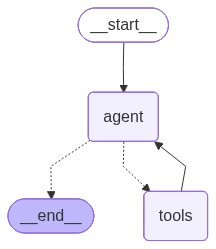

In [24]:
display(Image(agent_manual.get_graph().draw_mermaid_png()))

# ---------------------------------------------------------------------------
# 4. EJECUCIÓN INTERACTIVA
# ---------------------------------------------------------------------------

In [25]:
EJEMPLO_QUERIES = [
    "Dame un resumen general del dataset de transacciones.",
    "¿Qué tipos de transacción tienen más fraude? Explica los patrones.",
    "Muéstrame las transacciones de mayor riesgo superiores a 500,000.",
    "¿Hay discrepancias de saldo que indiquen fraude? ¿Cuántas?",
    "¿En qué horas del día ocurre más fraude y por qué crees que es así?",
    "Calcula la exposición total al fraude en transferencias (TRANSFER) y cash-out (CASH-OUT).",
]


In [26]:
def run_agent(query: str, use_manual_graph: bool = False) -> str:
    """Ejecuta el agente ReAct con la query del analista."""
    graph = agent_manual if use_manual_graph else agent_prebuilt
    result = graph.invoke({"messages": [("user", query)]})
    return result["messages"][-1].content


In [27]:
def interactive_demo():
    """Demo interactivo con preguntas predefinidas."""
    print("\n" + "=" * 70)
    print("  ReAct Agent — Detección de Fraude PaySim")
    print("  Dataset: https://www.kaggle.com/datasets/ealaxi/paysim1")
    print("=" * 70)

    for i, query in enumerate(EJEMPLO_QUERIES, 1):
        print(f"\n{'─' * 70}")
        print(f"[{i}/{len(EJEMPLO_QUERIES)}] PREGUNTA: {query}")
        print("─" * 70)
        respuesta = run_agent(query)
        print(f"RESPUESTA:\n{respuesta}")

    # Modo libre
    print(f"\n{'─' * 70}")
    print("💬 Modo interactivo — escribe tu pregunta (o 'salir'):")
    while True:
        user_input = input("\n> ").strip()
        if user_input.lower() in ("salir", "exit", "quit", ""):
            break
        respuesta = run_agent(user_input)
        print(f"\n{respuesta}")


In [28]:
interactive_demo()


  ReAct Agent — Detección de Fraude PaySim
  Dataset: https://www.kaggle.com/datasets/ealaxi/paysim1

──────────────────────────────────────────────────────────────────────
[1/6] PREGUNTA: Dame un resumen general del dataset de transacciones.
──────────────────────────────────────────────────────────────────────
RESPUESTA:
Aquí tienes el resumen completo del dataset **PaySim** con **50,000 transacciones** analizadas:

---

## 📊 Resumen General del Dataset

### 🔢 Volumen Total
| Métrica | Valor |
|---|---|
| **Total de transacciones** | 50,000 |
| **Fraudes detectados** | 0 (0.00%) |
| **Fraudes bloqueados** | 0 |

---

### 💳 Distribución por Tipo de Transacción
| Tipo | Cantidad | % del Total |
|---|---|---|
| **CASH-OUT** | 17,456 | 34.9% |
| **PAYMENT** | 16,954 | 33.9% |
| **CASH-IN** | 11,107 | 22.2% |
| **TRANSFER** | 3,960 | 7.9% |
| **DEBIT** | 523 | 1.0% |

---

### 💰 Estadísticas de Montos (en unidades monetarias)
| Estadística | Valor |
|---|---|
| **Monto promedio** | $50,2